## Aphasia vs Dementia Mainconcept Analysis

In [47]:
import pandas as pd
import numpy as np

dementia_features_df = pd.read_csv('../../data/classification/dementia_mainconcept_features_update_qsub.csv') 
aphasia_features_df = pd.read_csv('../../data/classification/aphasia_mainconcept_features_update_qsub.csv')
  # Replace with the actual filename
print(dementia_features_df.info())
print(aphasia_features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   participant                             94 non-null     object 
 1   total_utterances                        94 non-null     int64  
 2   distance_to_centroid                    94 non-null     float64
 3   num_unique_main_concepts                94 non-null     int64  
 4   num_total_main_concepts                 94 non-null     int64  
 5   unique_main_concept_match_ratio         94 non-null     float64
 6   total_main_concept_match_ratio          94 non-null     float64
 7   sequence_score_mainconcept              94 non-null     float64
 8   local_coherence_mainconcept             94 non-null     float64
 9   global_coherence_mainconcept            94 non-null     float64
 10  num_topic_switching                     94 non-null     int64  


In [48]:
participants_df = pd.read_csv('../../data/classification/combined_patient_data_111725.csv')  
print(participants_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Corpus             309 non-null    object 
 1   participant        309 non-null    object 
 2   age                302 non-null    object 
 3   sex                309 non-null    object 
 4   diagnosis          309 non-null    object 
 5   WAB score          102 non-null    float64
 6   standardized MOCA  132 non-null    float64
 7   gen_diagnosis      309 non-null    object 
dtypes: float64(2), object(6)
memory usage: 19.4+ KB
None


In [49]:
# Conditionally create combined ID only if Participant_Code starts with a numerical value (digit)
participants_df['combined_id'] = np.where(
    participants_df['participant'].str[0].str.isdigit(),
    participants_df['Corpus'].str.lower().str.strip() + participants_df['participant'].str.strip(),
    participants_df['participant'].str.strip()  # Fallback to just participant code if condition not met
)

participants_df['combined_id'] = participants_df['combined_id'].str.lower()

# Output the combined IDs
print(participants_df['combined_id'].tolist())

['delaware02-1', 'delaware03-1', 'delaware04-1', 'delaware05-1', 'delaware07-1', 'delaware08-1', 'delaware101-1', 'delaware12-1', 'delaware13-1', 'delaware200-1', 'delaware201-1', 'delaware203-1', 'delaware204-1', 'delaware208-1', 'delaware209-1', 'delaware214-1', 'delaware218-1', 'delaware220-1', 'delaware221-1', 'delaware224-1', 'delaware225-1', 'delaware226-1', 'delaware227-1', 'delaware228-1', 'delaware229-1', 'delaware233-1', 'delaware234-1', 'delaware235-1', 'delaware24-1', 'delaware244-1', 'delaware25-1', 'delaware270-1', 'delaware271-1', 'delaware276-1', 'delaware278-1', 'delaware279-1', 'delaware29-1', 'delaware30-1', 'delaware35-1', 'delaware36-1', 'delaware37-1', 'delaware38-1', 'delaware39-1', 'delaware42-1', 'delaware44-1', 'delaware45-1', 'delaware46-1', 'delaware48-1', 'delaware60-1', 'delaware62-1', 'delaware65-1', 'delaware67-1', 'delaware70-1', 'delaware77-1', 'delaware81-1', 'delaware84-1', 'delaware86-1', 'delaware87-1', 'delaware90-1', 'delaware92-1', 'delaware93-1

In [50]:
aphasia_df = participants_df[participants_df['gen_diagnosis'] == 'Aphasia']
dementia_df = participants_df[participants_df['gen_diagnosis'] == 'Dementia']
print(dementia_df.info())
print(aphasia_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 113 to 206
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Corpus             94 non-null     object 
 1   participant        94 non-null     object 
 2   age                87 non-null     object 
 3   sex                94 non-null     object 
 4   diagnosis          94 non-null     object 
 5   WAB score          0 non-null      float64
 6   standardized MOCA  66 non-null     float64
 7   gen_diagnosis      94 non-null     object 
 8   combined_id        94 non-null     object 
dtypes: float64(2), object(7)
memory usage: 7.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 207 to 308
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Corpus             102 non-null    object 
 1   participant        102 non-null    object 
 2   age              

In [51]:
# Conditionally create combined ID only if Participant_Code starts with a numerical value (digit)
aphasia_features_df['participant'] = aphasia_features_df['participant'].str.lower()
dementia_features_df['participant'] = dementia_features_df['participant'].str.lower()

### Check if any participants is missing in Aphasia features and participants data

In [52]:
# unique IDs from each side
p_ids = set(aphasia_df['combined_id'])
f_ids = set(aphasia_features_df['participant'])
print(len(p_ids)), 
print(len(f_ids))

# who is in participants_df but NOT in controls_features_df
missing_in_features = p_ids - f_ids

# who is in controls_features_df but NOT in participants_df
missing_in_participants = f_ids - p_ids

print("Missing in aphasia_features_df:", missing_in_features)
print("Missing in participants_df:", missing_in_participants)

102
102
Missing in aphasia_features_df: set()
Missing in participants_df: set()


### Check if any participants is missing in Controls and Dementia from features and participants data

In [53]:
from collections import Counter
dementia_features_df = pd.read_csv('../../data/classification/dementia_mainconcept_features_update_qsub.csv')  
dementia_features_df['participant'] = dementia_features_df['participant'].str.lower()# Conditionally create combined ID only if Participant_Code starts with a numerical value (digit)
dementia_features_df['participant'] = np.where(
    dementia_features_df['participant'].str[0].str.isdigit(),
    "delaware"+ dementia_features_df['participant'].str.strip(),
    dementia_features_df['participant'].str.strip()  # Fallback to just participant code if condition not met
)

print(dementia_features_df['participant'].tolist())
print(len(dementia_features_df))

missing_in_metadata = Counter(dementia_features_df['participant']) 
print(missing_in_metadata)

['baycrest11634', 'delaware22-1', 'rbn7927a', 'delaware75-1', 'delaware64-1', 'baycrest12828', 'jre5043a', 'baycrest2103', 'delaware32-1', 'delaware23-1', 'delaware232-1', 'due3951a', 'delaware18-1', 'baycrest8538', 'baycrest12756', 'bdy3628a', 'baycrest12814', 'kcr7045a', 'delaware19-1', 'delaware277-1', 'delaware47-1', 'delaware50-1', 'delaware14-1', 'delaware216-1', 'bmn3031b', 'bbw8512a', 'delaware52-1', 'lby4645a', 'delaware58-1', 'dcr7644a', 'delaware59-1', 'baycrest11976', 'delaware88-1', 'mvs4058a', 'rcl5752', 'delaware01-1', 'delaware09-1', 'delaware10-1', 'delaware17-1', 'emh9057a', 'amr6628a', 'jks7696a', 'delaware11-1', 'tbd4254a', 'delaware31-1', 'delaware95-1', 'hwn0674a', 'delaware54-1', 'delaware61-1', 'delaware63-1', 'jbh5314a', 'delaware79-1', 'delaware68-1', 'lrw4117a', 'delaware43-1', 'baycrest12257', 'delaware16-1', 'delaware21-1', 'delaware34-1', 'chp4775a', 'delaware27-1', 'nhe3782a', 'delaware71-1', 'baycrest12813', 'delaware78-1', 'delaware06-1', 'bfi6092a', 'd

In [54]:
# unique IDs from each side
p_ids = set(dementia_df['combined_id'])
f_ids = set(dementia_features_df['participant'])

# who is in participants_df but NOT in controls_features_df
missing_in_features = p_ids - f_ids

# who is in controls_features_df but NOT in participants_df
missing_in_participants = f_ids - p_ids

print("Missing in dementia_features_df:", missing_in_features)
print("Missing in participants_df:", missing_in_participants)

Missing in dementia_features_df: set()
Missing in participants_df: set()


### Merge and concatenate Dataframe Dementia and Aphasia

In [55]:
aphasia_df['participant'] = aphasia_df['combined_id']
aphasia_df = aphasia_df.drop(columns=['combined_id'])

aphasia_combined_df = pd.merge(aphasia_df, aphasia_features_df, on='participant', how='inner')
aphasia_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  102 non-null    object 
 1   participant                             102 non-null    object 
 2   age                                     102 non-null    object 
 3   sex                                     102 non-null    object 
 4   diagnosis                               102 non-null    object 
 5   WAB score                               102 non-null    float64
 6   standardized MOCA                       0 non-null      float64
 7   gen_diagnosis                           102 non-null    object 
 8   total_utterances                        102 non-null    int64  
 9   distance_to_centroid                    102 non-null    float64
 10  num_unique_main_concepts                102 non-null    int64 

/scratch/ipykernel_3593947/1058581605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aphasia_df['participant'] = aphasia_df['combined_id']


In [56]:
dementia_df['participant'] = dementia_df['combined_id']
dementia_df = dementia_df.drop(columns=['combined_id'])

dementia_combined_df = pd.merge(dementia_df, dementia_features_df, on='participant', how='inner')
print(len(dementia_df))
# print(len(dementia_features_df))
dementia_combined_df.info()

94
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  94 non-null     object 
 1   participant                             94 non-null     object 
 2   age                                     87 non-null     object 
 3   sex                                     94 non-null     object 
 4   diagnosis                               94 non-null     object 
 5   WAB score                               0 non-null      float64
 6   standardized MOCA                       66 non-null     float64
 7   gen_diagnosis                           94 non-null     object 
 8   total_utterances                        94 non-null     int64  
 9   distance_to_centroid                    94 non-null     float64
 10  num_unique_main_concepts                94 non-null     int64

/scratch/ipykernel_3593947/2793744067.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dementia_df['participant'] = dementia_df['combined_id']


## Concetenate the patients data

In [57]:
all_df = pd.concat([dementia_combined_df, aphasia_combined_df], ignore_index=True)
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Corpus                                  196 non-null    object 
 1   participant                             196 non-null    object 
 2   age                                     189 non-null    object 
 3   sex                                     196 non-null    object 
 4   diagnosis                               196 non-null    object 
 5   WAB score                               102 non-null    float64
 6   standardized MOCA                       66 non-null     float64
 7   gen_diagnosis                           196 non-null    object 
 8   total_utterances                        196 non-null    int64  
 9   distance_to_centroid                    196 non-null    float64
 10  num_unique_main_concepts                196 non-null    int64 

In [58]:
columns_to_drop = ['sex','Corpus','WAB score', 'diagnosis', 'age', 'standardized MOCA', ]
num_df = all_df.drop(columns=columns_to_drop)
num_cols = num_df.columns
print(num_cols)

Index(['participant', 'gen_diagnosis', 'total_utterances',
       'distance_to_centroid', 'num_unique_main_concepts',
       'num_total_main_concepts', 'unique_main_concept_match_ratio',
       'total_main_concept_match_ratio', 'sequence_score_mainconcept',
       'local_coherence_mainconcept', 'global_coherence_mainconcept',
       'num_topic_switching', 'ratio_topic_switching_percent',
       'num_missing_referent', 'ratio_missing_referent_percent',
       'num_tangential_utterance', 'ratio_tangential_utterance_percent',
       'num_propositional_repetition',
       'ratio_propositional_repetition_percent', 'num_filler',
       'ratio_filler_percent', 'num_conceptual_incongruence',
       'ratio_conceptual_incongruence_percent', 'num_coherent',
       'ratio_coherent_percent'],
      dtype='object')


In [59]:
aph_df = num_df[num_df['gen_diagnosis'] == 'Aphasia']
dem_df = num_df[num_df['gen_diagnosis'] == 'Dementia']

print(f"Number of patients: {len(aph_df)}")
print(f"Number of controls: {len(dem_df)}")

Number of patients: 102
Number of controls: 94


### Density Plot after z-score normalization

In [60]:
import numpy as np
import pandas as pd

# columns to scale: all numeric except the label column(s)
num_cols = num_df.select_dtypes(include='number').columns.tolist()
for c in ['group']:
    if c in num_cols:
        num_cols.remove(c)

# fit params on the whole df
means = num_df[num_cols].mean()
stds  = num_df[num_cols].std(ddof=0).replace(0, np.nan)  # avoid div-by-zero

# normalized copy
df_z = all_df.copy()
df_z[num_cols] = (num_df[num_cols] - means) / stds

# if you prefer to keep zero-variance columns as 0 instead of NaN:
df_z[num_cols] = df_z[num_cols].fillna(0)

# split back to groups (normalized)
dem_df_z = df_z[df_z['gen_diagnosis'] == 'Dementia'].copy()
aph_df_z = df_z[df_z['gen_diagnosis'] == 'Aphasia'].copy()


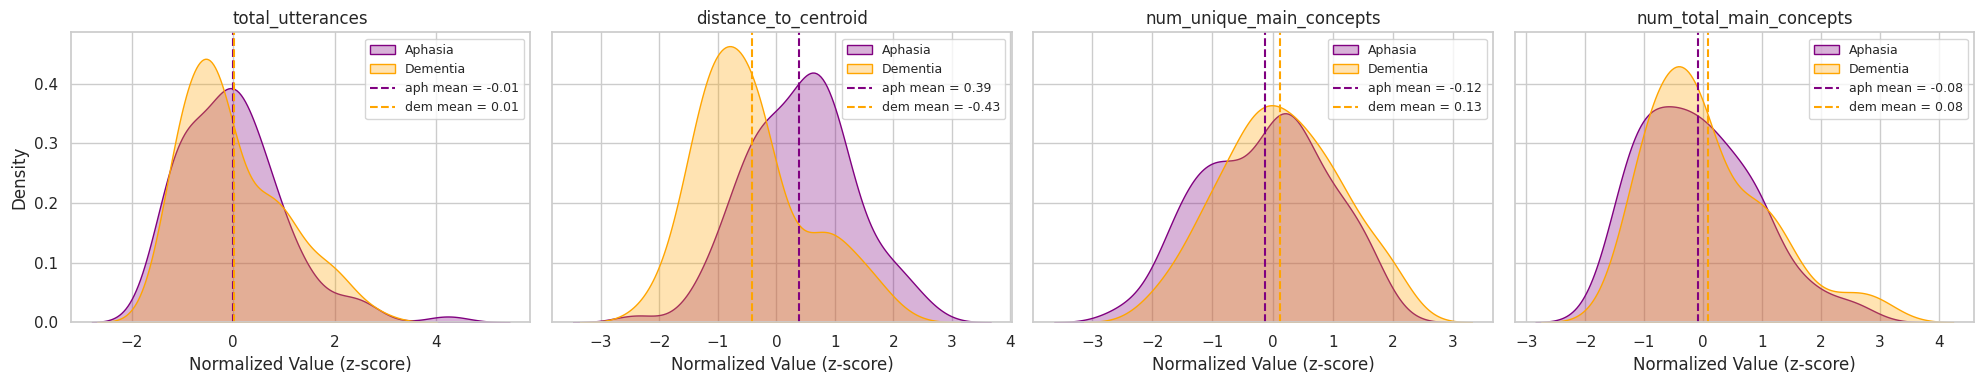

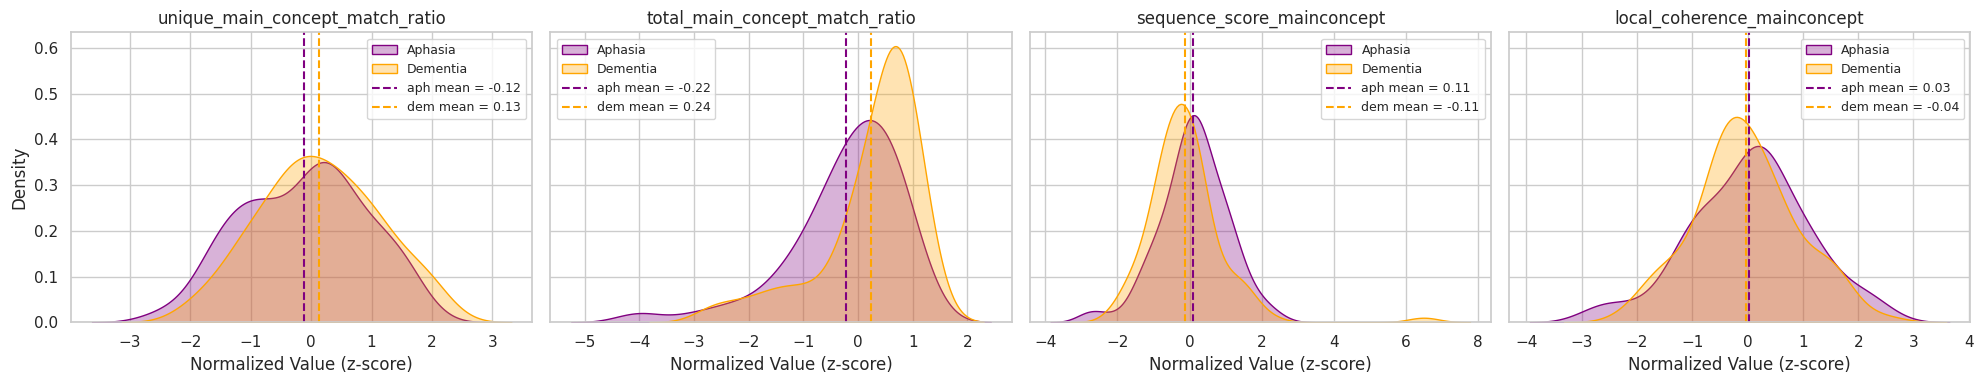

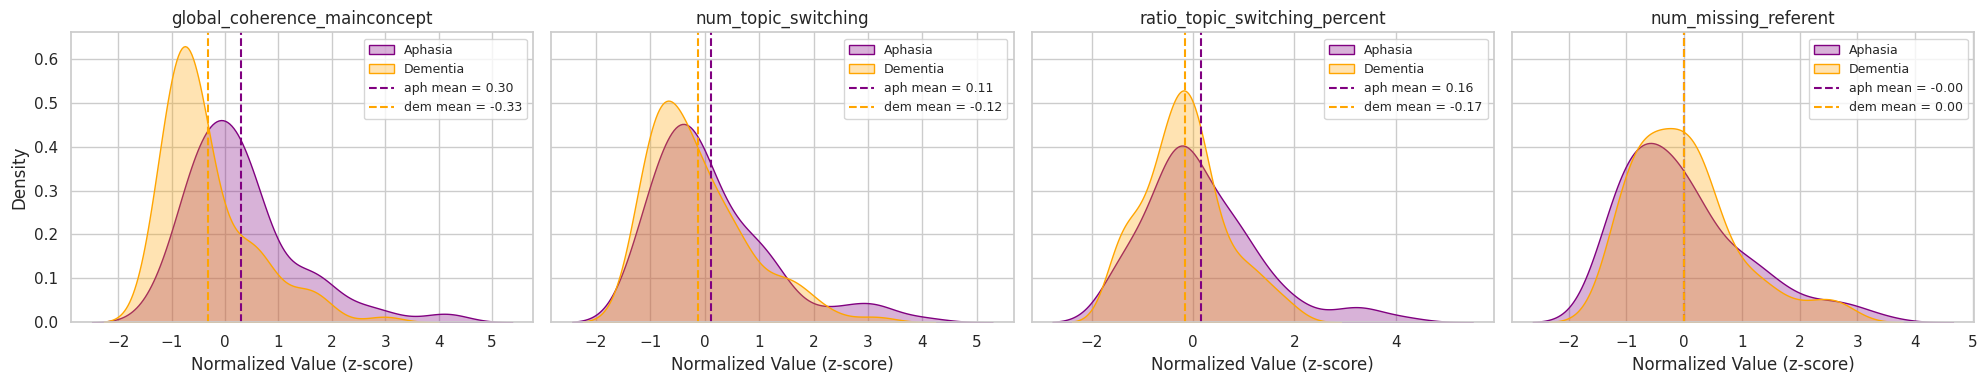

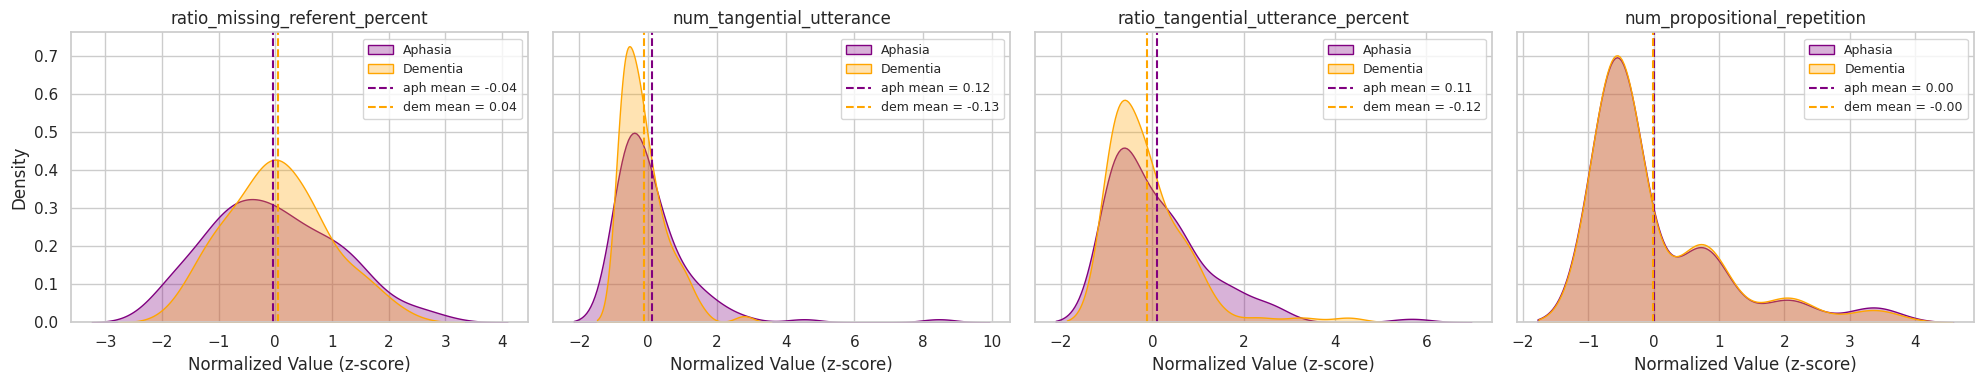

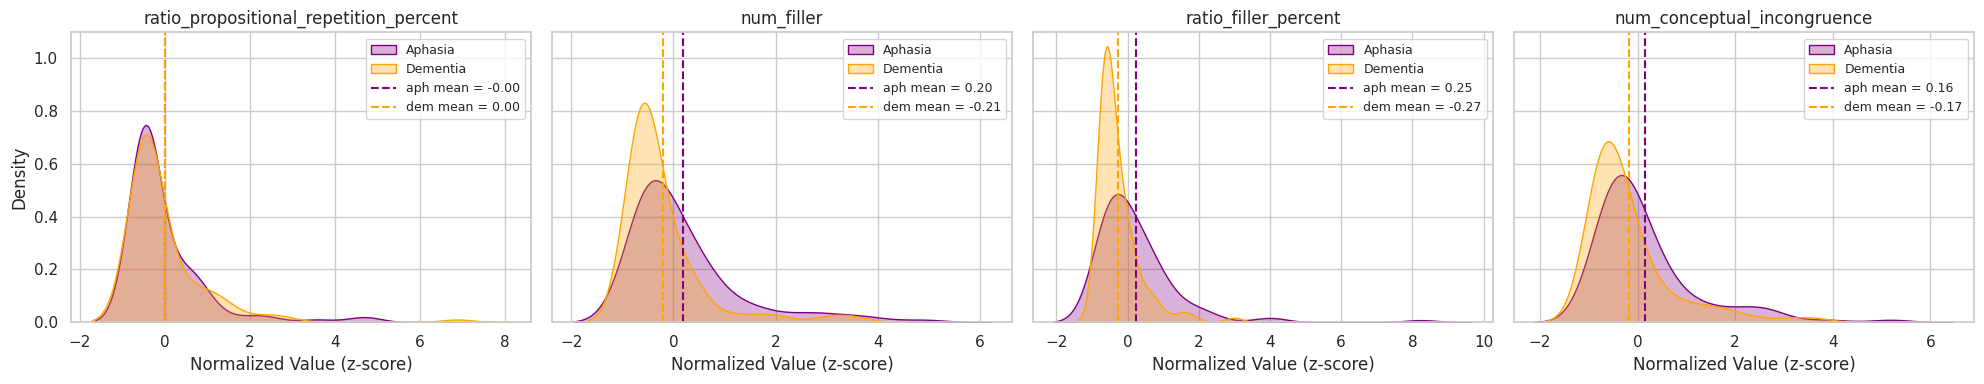

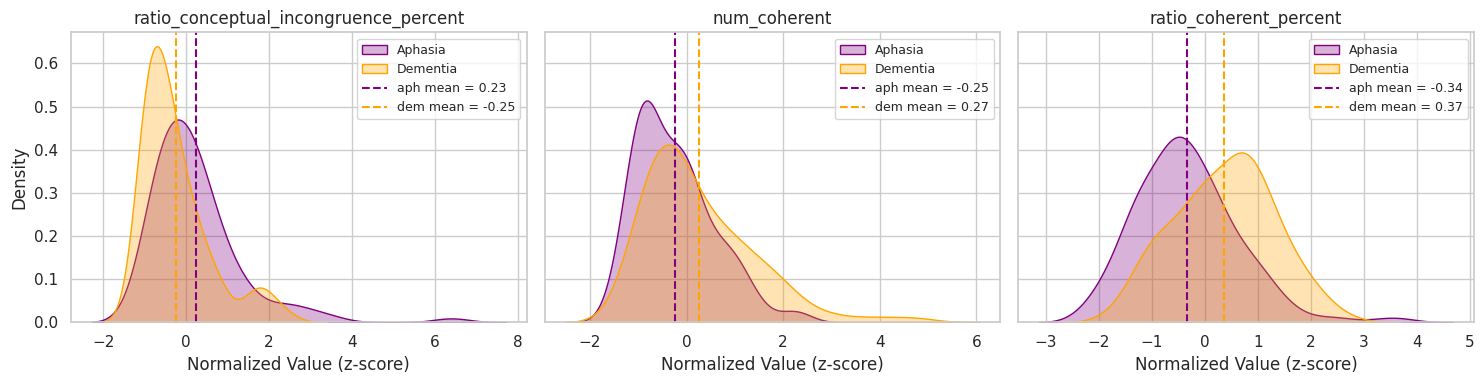

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plots_per_row = 4

for i in range(0, len(num_cols), plots_per_row):
    cols_batch = num_cols[i:i + plots_per_row]

    fig, axes = plt.subplots(
        1, len(cols_batch),
        figsize=(5 * len(cols_batch), 4),
        sharey=True
    )

    # Handle case where there's only one subplot
    if len(cols_batch) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_batch):
        # KDE plots
        sns.kdeplot(
            data=aph_df_z,
            x=col,
            fill=True,
            alpha=0.3,
            color='purple',
            label='Aphasia',
            ax=ax
        )
        sns.kdeplot(
            data=dem_df_z,
            x=col,
            fill=True,
            alpha=0.3,
            color='orange',
            label='Dementia',
            ax=ax
        )

        # Mean
        median_ctrl = aph_df_z[col].mean()
        median_pat  = dem_df_z[col].mean()

        ax.axvline(
            median_ctrl,
            color='purple',
            linestyle='--',
            linewidth=1.5,
            label=f'aph mean = {median_ctrl:.2f}'
        )
        ax.axvline(
            median_pat,
            color='orange',
            linestyle='--',
            linewidth=1.5,
            label=f'dem mean = {median_pat:.2f}'
        )

        ax.set_title(col)
        ax.set_xlabel('Normalized Value (z-score)')
        ax.set_ylabel('Density')

        # ✅ Individual legend per subplot
        ax.legend(fontsize=9)

    fig.tight_layout()
    plt.show()


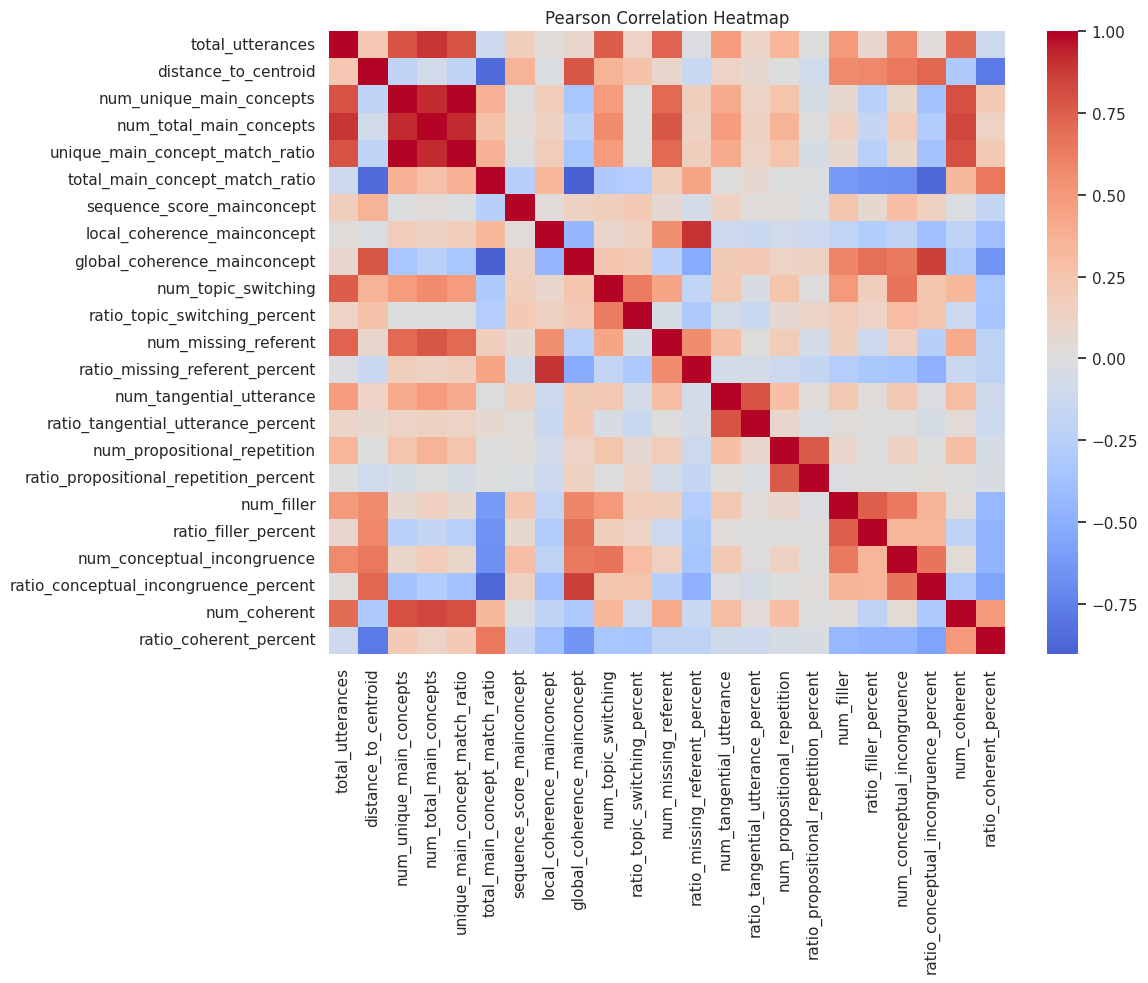

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Pearson correlation
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

In [67]:
import numpy as np

# Take absolute values
corr_abs = corr.abs()

# Mask the diagonal (self correlations)
np.fill_diagonal(corr_abs.values, 0)

# Find pairs above threshold
high_corr_pairs = np.where(corr_abs > 0.8)

pairs = []
for i, j in zip(*high_corr_pairs):
    if i < j:  # avoid duplicates
        pairs.append((
            corr.index[i],
            corr.columns[j],
            corr.iloc[i, j]   # original (signed) correlation value
        ))

for a, b, r in pairs:
    print(f"{a}  <-->  {b}   r = {r:.3f}")

total_utterances  <-->  num_total_main_concepts   r = 0.895
distance_to_centroid  <-->  total_main_concept_match_ratio   r = -0.853
num_unique_main_concepts  <-->  num_total_main_concepts   r = 0.923
num_unique_main_concepts  <-->  unique_main_concept_match_ratio   r = 1.000
num_unique_main_concepts  <-->  num_coherent   r = 0.803
num_total_main_concepts  <-->  unique_main_concept_match_ratio   r = 0.923
num_total_main_concepts  <-->  num_coherent   r = 0.843
unique_main_concept_match_ratio  <-->  num_coherent   r = 0.803
total_main_concept_match_ratio  <-->  global_coherence_mainconcept   r = -0.903
total_main_concept_match_ratio  <-->  ratio_conceptual_incongruence_percent   r = -0.868
local_coherence_mainconcept  <-->  ratio_missing_referent_percent   r = 0.896
global_coherence_mainconcept  <-->  ratio_conceptual_incongruence_percent   r = 0.865


In [73]:
cols_to_remove = []
cols_to_remove.extend([
    "total_utterances",
    "num_unique_main_concepts",
    "num_total_main_concepts",
    "local_coherence_mainconcept",
    "global_coherence_mainconcept",
    "num_coherent",
    # "ratio_conceptual_incongruence_percent",
    "total_main_concept_match_ratio",
])

df_clean = num_df.drop(columns=cols_to_remove, errors="ignore")
feature_cols = df_clean.columns

corr = df_clean.corr(numeric_only=True)

In [74]:
import numpy as np

# Take absolute values
corr_abs = corr.abs()

# Mask the diagonal (self correlations)
np.fill_diagonal(corr_abs.values, 0)

# Find pairs above threshold
high_corr_pairs = np.where(corr_abs > 0.8)

pairs = []
for i, j in zip(*high_corr_pairs):
    if i < j:  # avoid duplicates
        pairs.append((
            corr.index[i],
            corr.columns[j],
            corr.iloc[i, j]   # original (signed) correlation value
        ))

for a, b, r in pairs:
    print(f"{a}  <-->  {b}   r = {r:.3f}")

### Logistic Regression Classification

In [96]:
df_ml = df_z.drop(columns=cols_to_remove + columns_to_drop, errors='ignore').copy()
df_ml = df_ml[df_ml['gen_diagnosis'].isin(['Dementia', 'Aphasia'])].copy()
df_ml['label'] = (df_ml['gen_diagnosis'] == 'Aphasia').astype(int)
df_ml = df_ml.drop(columns=['gen_diagnosis'], errors='ignore')
participants = df_ml['participant']
print(df_ml.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   participant                             196 non-null    object 
 1   distance_to_centroid                    196 non-null    float64
 2   unique_main_concept_match_ratio         196 non-null    float64
 3   sequence_score_mainconcept              196 non-null    float64
 4   num_topic_switching                     196 non-null    float64
 5   ratio_topic_switching_percent           196 non-null    float64
 6   num_missing_referent                    196 non-null    float64
 7   ratio_missing_referent_percent          196 non-null    float64
 8   num_tangential_utterance                196 non-null    float64
 9   ratio_tangential_utterance_percent      196 non-null    float64
 10  num_propositional_repetition            196 non-null    float6

In [97]:
y = df_ml['label']

X = df_ml.drop(
    columns=[
        'label',
        'participant',      # or 'combined_id' depending on what you kept
    ],
    errors='ignore'
)


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'  # good for class imbalance
)

logreg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [99]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7

Classification report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68        19
           1       0.71      0.71      0.71        21

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



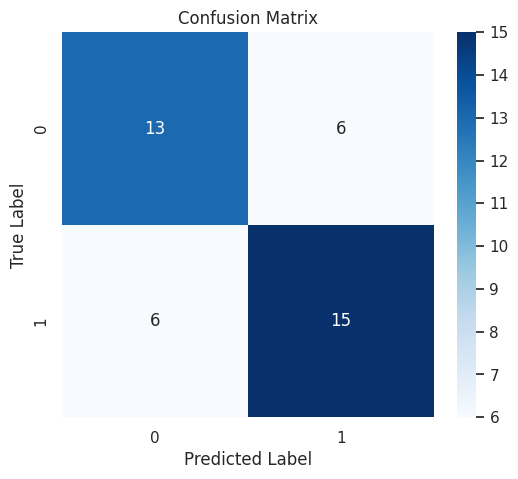

In [100]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [102]:
# Boolean masks for errors
false_neg_mask = (y_test == 1) & (y_pred == 0)
false_pos_mask = (y_test == 0) & (y_pred == 1)

# Get participant codes by aligning indices to the original df
false_negative_participants = df_ml.loc[X_test.index[false_neg_mask], 'participant'].tolist()
false_positive_participants = df_ml.loc[X_test.index[false_pos_mask], 'participant'].tolist()

print("False Negatives:", false_negative_participants)
print("False Positives:", false_positive_participants)

False Negatives: ['adler15a', 'williamson11a', 'adler03a', 'wright203a', 'fridriksson11a', 'whiteside20a']
False Positives: ['delaware95-1', 'delaware06-1', 'mvs4058a', 'baycrest12829', 'nhe3782a', 'lrw4117a']


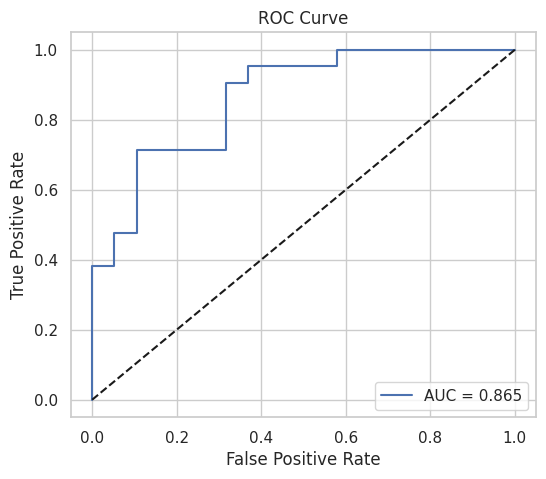

In [103]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = logreg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_value = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [104]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", ascending=False)

print(coef_df)

                                   feature  coefficient
0                     distance_to_centroid     0.827123
7                 num_tangential_utterance     0.450784
12                    ratio_filler_percent     0.198951
4            ratio_topic_switching_percent     0.173886
3                      num_topic_switching     0.146396
6           ratio_missing_referent_percent     0.070472
2               sequence_score_mainconcept    -0.011978
9             num_propositional_repetition    -0.018803
11                              num_filler    -0.028828
14   ratio_conceptual_incongruence_percent    -0.045805
10  ratio_propositional_repetition_percent    -0.053128
5                     num_missing_referent    -0.120595
8       ratio_tangential_utterance_percent    -0.131317
15                  ratio_coherent_percent    -0.140992
1          unique_main_concept_match_ratio    -0.180569
13             num_conceptual_incongruence    -0.517230


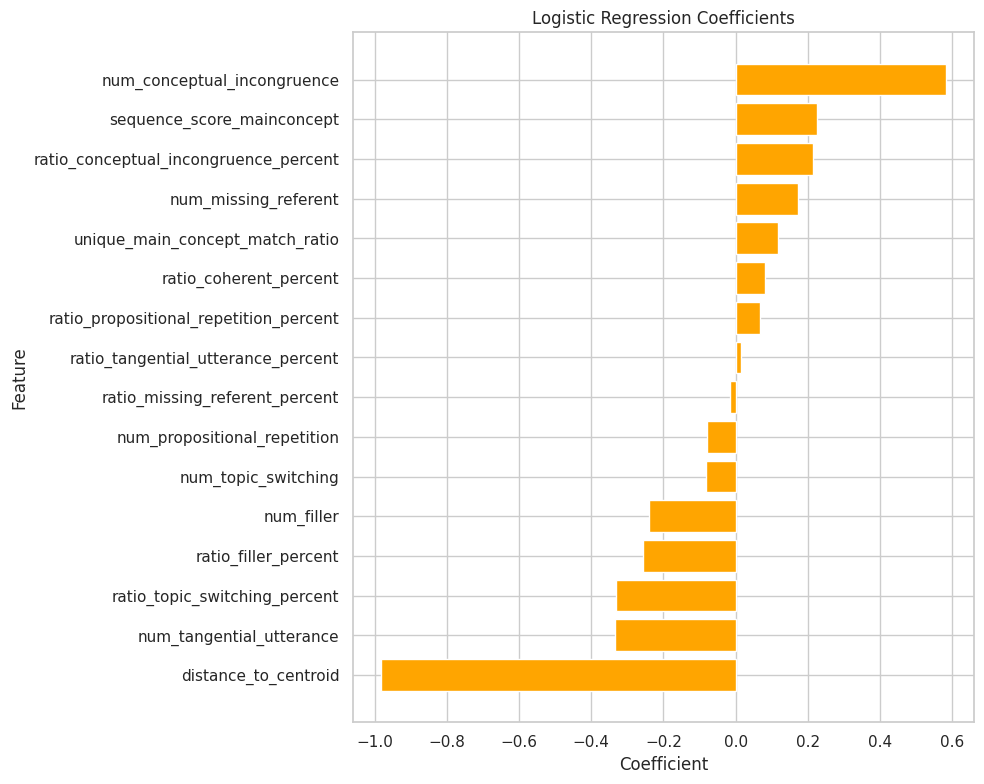

In [83]:
import matplotlib.pyplot as plt

# Sort by coefficient value (descending)
coef_df_sorted = coef_df.sort_values("coefficient", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"], color="orange")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")

# Put the highest coefficient at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [84]:
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_sorted = coef_df.sort_values('abs_coef', ascending=False)
coef_sorted

,feature,coefficient,abs_coef
0,distance_to_centroid,-0.983003,0.983003
13,num_conceptual_incongruence,0.582387,0.582387
7,num_tangential_utterance,-0.333573,0.333573
4,ratio_topic_switching_percent,-0.330636,0.330636
12,ratio_filler_percent,-0.256318,0.256318
11,num_filler,-0.240367,0.240367
2,sequence_score_mainconcept,0.224888,0.224888
14,ratio_conceptual_incongruence_percent,0.215253,0.215253
5,num_missing_referent,0.173778,0.173778
1,unique_main_concept_match_ratio,0.118282,0.118282


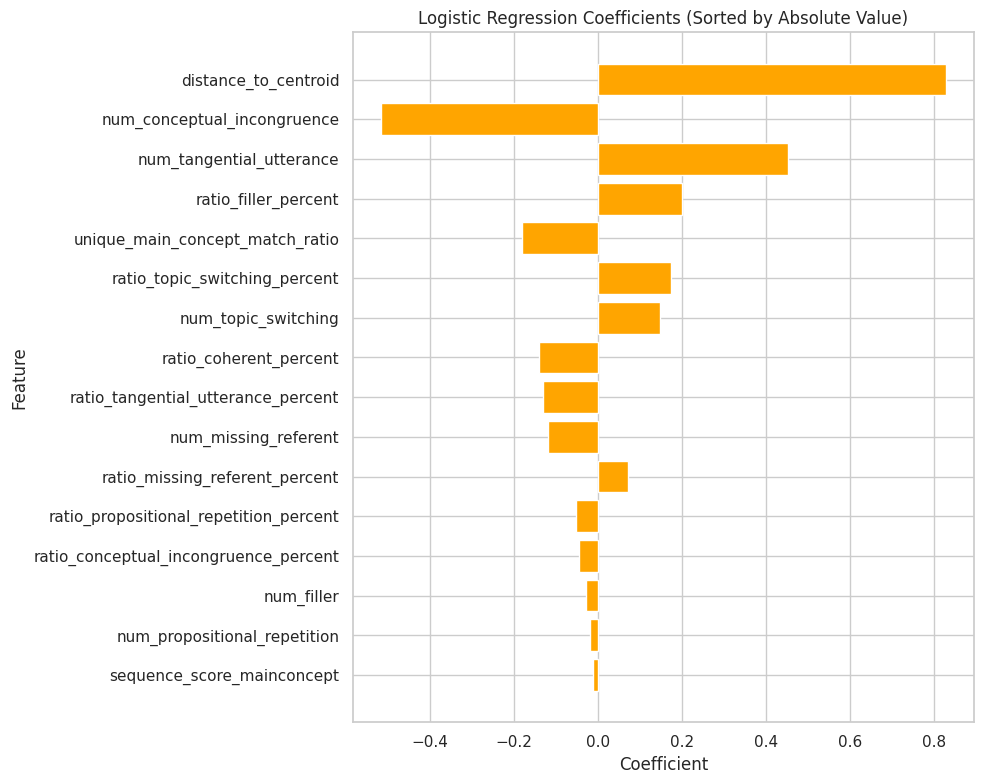

In [105]:

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df_sorted = coef_df.sort_values("abs_coef", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"], color="orange")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients (Sorted by Absolute Value)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cross Validation 5 Folds


===== CONFUSION MATRICES (5 folds) =====

Fold 1:
[[16  3]
 [ 7 14]]

Fold 2:
[[ 8 11]
 [ 5 15]]

Fold 3:
[[12  7]
 [ 6 14]]

Fold 4:
[[15  4]
 [ 8 12]]

Fold 5:
[[ 9  9]
 [ 8 13]]

===== FINAL METRICS =====
Accuracy per fold: [0.75  0.59  0.667 0.692 0.564]
Mean Accuracy: 0.653
AUC per fold: [0.789 0.608 0.718 0.734 0.646]
Mean AUC: 0.699

===== GLOBAL CONFUSION MATRIX (all folds combined) =====
[[60 34]
 [34 68]]


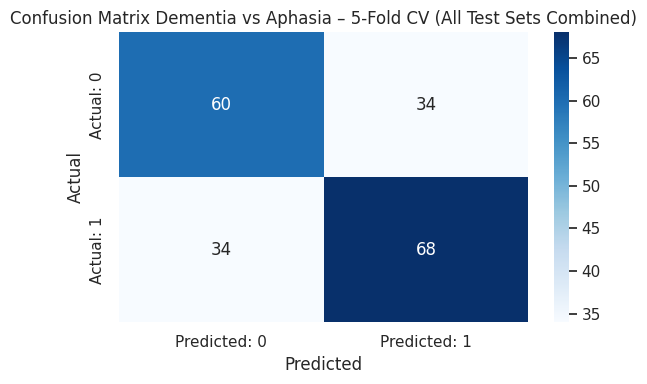

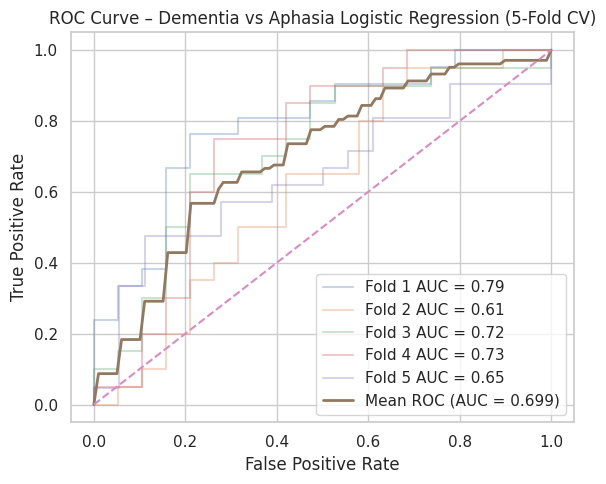

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)

# Logistic Regression Classifier
logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
roc_aucs = []
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)

# 👉 store per-fold curves if you want to plot them
fprs = []
tprs = []

# 👉 NEW: to build one global confusion matrix
y_true_all = []
y_pred_all = []
fold_results = [] 

print("\n===== CONFUSION MATRICES (5 folds) =====\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    ids_test = participants[test_idx]  # participant IDs for lookup

    # Train & Predict
    logreg.fit(X_train_fold, y_train_fold)
    y_pred_fold = logreg.predict(X_test_fold)
    y_prob_fold = logreg.predict_proba(X_test_fold)[:, 1]  # probability for ROC

    # 👉 collect for global confusion matrix
    y_true_all.extend(y_test_fold)
    y_pred_all.extend(y_pred_fold)

    # False negative = true=1 patient, predicted=0
    fn_mask = (y_test_fold.values == 1) & (y_pred_fold == 0)
    false_negatives = ids_test[fn_mask]

    # False positive = true=0 control, predicted=1
    fp_mask = (y_test_fold.values == 0) & (y_pred_fold == 1)
    false_positives = ids_test[fp_mask]

    fold_results.append({
        "fold": fold,
        "false_negatives": false_negatives.tolist(),
        "false_positives": false_positives.tolist()
    })

    # Confusion matrix per fold (optional print)
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    print(f"Fold {fold}:\n{cm}\n")

    # Metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_prob_fold)
    accuracies.append(acc)
    roc_aucs.append(auc)

    # ROC curve aggregation
    fpr, tpr, _ = roc_curve(y_test_fold, y_prob_fold)
    fprs.append(fpr)
    tprs.append(tpr)

    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# ======= Average ROC curve =======
mean_tpr /= cv.n_splits
mean_tpr[-1] = 1.0
mean_auc = np.mean(roc_aucs)

# ======= Print Final Metrics =======
print("===== FINAL METRICS =====")
print(f"Accuracy per fold: {np.round(accuracies,3)}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"AUC per fold: {np.round(roc_aucs,3)}")
print(f"Mean AUC: {mean_auc:.3f}")

# ======= 👉 ONE GLOBAL CONFUSION MATRIX ACROSS ALL 5 FOLDS =======
final_cm = confusion_matrix(y_true_all, y_pred_all)
print("\n===== GLOBAL CONFUSION MATRIX (all folds combined) =====")
print(final_cm)

# Confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: 0", "Predicted: 1"],
    yticklabels=["Actual: 0", "Actual: 1"]
)
plt.title("Confusion Matrix Dementia vs Aphasia – 5-Fold CV (All Test Sets Combined)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ======= 👉 ROC CURVE PLOT (mean across 5 folds) =======
plt.figure(figsize=(6, 5))

# (optional) plot each fold ROC lightly
for i, (fpr, tpr) in enumerate(zip(fprs, tprs), start=1):
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i} AUC = {roc_aucs[i-1]:.2f}")

# plot mean ROC
plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {mean_auc:.3f})", linewidth=2)

# diagonal line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Dementia vs Aphasia Logistic Regression (5-Fold CV)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Diagnosis of False postives and False Negatives 

In [107]:
misclassified_df = pd.DataFrame(fold_results)

for result in fold_results:
    fold = result["fold"]
    fns = result["false_negatives"]
    fps = result["false_positives"]

    print(f"\n===== Fold {fold} =====")

    # ---- False Negatives (Patient predicted as Control) ----
    print("\nFalse Negatives (Patient wrongly labeled Control):")
    if len(fns) > 0:
        display(participants_df[participants_df['combined_id'].isin(fns)])
    else:
        print("None")

    # ---- False Positives (Control predicted as Patient) ----
    print("\nFalse Positives (Control wrongly labeled Patient):")
    if len(fps) > 0:
        display(participants_df[participants_df['combined_id'].isin(fps)])
    else:
        print("None")


===== Fold 1 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
245,MMA,mma11a,70,M,Anomic,91.4,NaN,Aphasia,mma11a
250,Richardson,richardson08a,48,M,Anomic,92.6,NaN,Aphasia,richardson08a
275,UNH,UNH11b,65,F,NotAphasicbyWAB,94.3,NaN,Aphasia,unh11b
291,Whiteside,whiteside17a,63,M,NotAphasicbyWAB,95.1,NaN,Aphasia,whiteside17a
297,Williamson,williamson07a,64,M,Anomic,92.2,NaN,Aphasia,williamson07a
303,Wozniak,wozniak04a,79,M,Anomic,84.5,NaN,Aphasia,wozniak04a
307,Wright,wright202a,63,F,Anomic,89.5,NaN,Aphasia,wright202a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
143,Delaware,50-1,79.0,M,MCI,NaN,20.0,Dementia,delaware50-1
195,Hopkins,LRW4117a,72.0,F,PPA,NaN,NaN,Dementia,lrw4117a
204,Hopkins,RWN7022a,NaN,M,PPA,NaN,NaN,Dementia,rwn7022a



===== Fold 2 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
208,ACWT,ACWT04a,26,F,NotAphasicbyWAB,96.0,NaN,Aphasia,acwt04a
227,Baycrest,baycrest12072a,46,M,Aphasia,52.3,NaN,Aphasia,baycrest12072a
241,Fridriksson,fridriksson11a,35,F,NotAphasicbyWAB,99.6,NaN,Aphasia,fridriksson11a
257,Richardson,richardson20a,33,F,NotAphasicbyWAB,95.5,NaN,Aphasia,richardson20a
276,UNH,UNH14a,59,F,Conduction,85.3,NaN,Aphasia,unh14a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
124,Delaware,20-1,83.0,M,MCI,NaN,23.0,Dementia,delaware20-1
136,Delaware,32-1,67.0,F,MCI,NaN,25.0,Dementia,delaware32-1
150,Delaware,59-1,75.0,F,MCI,NaN,27.0,Dementia,delaware59-1
154,Delaware,66-1,72.0,F,MCI,NaN,20.0,Dementia,delaware66-1
167,Baycrest,Baycrest11976,88.0,M,MCI,NaN,21.0,Dementia,baycrest11976
185,Hopkins,DCR7644a,71.0,F,PPA,NaN,NaN,Dementia,dcr7644a
190,Hopkins,JBH5314a,73.0,F,PPA,NaN,NaN,Dementia,jbh5314a
191,Hopkins,JKS7696a,74.0,M,PPA,NaN,NaN,Dementia,jks7696a
194,Hopkins,LBY4645a,67.0,F,PPA,NaN,NaN,Dementia,lby4645a
196,Hopkins,MJE8703a,NaN,M,PPA,NaN,NaN,Dementia,mje8703a



===== Fold 3 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
216,Adler,adler05a,68,F,Conduction,65.5,NaN,Aphasia,adler05a
221,Baycrest,baycrest12331a,68,F,Aphasia,90.8,NaN,Aphasia,baycrest12331a
229,Elman,elman05a,48,M,Anomic,85.7,NaN,Aphasia,elman05a
258,Richardson,richardson21a,51,F,NotAphasicbyWAB,96.5,NaN,Aphasia,richardson21a
260,Richardson,richardson27a,41,M,Conduction,73.9,NaN,Aphasia,richardson27a
288,Whiteside,whiteside14a,40,F,Wernicke's,71.8,NaN,Aphasia,whiteside14a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
119,Delaware,15-1,75.0,M,MCI,NaN,24.0,Dementia,delaware15-1
147,Delaware,55-1,65.0,F,MCI,NaN,28.0,Dementia,delaware55-1
157,Delaware,71-1,73.0,F,MCI,NaN,23.0,Dementia,delaware71-1
169,Baycrest-PPA,Baycrest12756,60.0,M,PPA,NaN,14.0,Dementia,baycrest12756
171,Baycrest,Baycrest12814,78.0,F,AD,NaN,14.0,Dementia,baycrest12814
173,Baycrest-PPA,Baycrest12829,71.0,M,PPA,NaN,21.0,Dementia,baycrest12829
175,Baycrest-PPA,Baycrest13188,70.0,M,PPA,NaN,23.0,Dementia,baycrest13188



===== Fold 4 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
212,ACWT,ACWT12a,83,F,Conduction,79.5,NaN,Aphasia,acwt12a
231,Elman,elman10a,59,F,Anomic,93.2,NaN,Aphasia,elman10a
237,Fridriksson,fridriksson05a,58,F,Anomic,92.7,NaN,Aphasia,fridriksson05a
238,Fridriksson,fridriksson07a,77,F,NotAphasicbyWAB,97.9,NaN,Aphasia,fridriksson07a
259,Richardson,richardson26a,58,M,Anomic,84.6,NaN,Aphasia,richardson26a
263,Richardson,richardson31a,49,M,NotAphasicbyWAB,95.0,NaN,Aphasia,richardson31a
292,Whiteside,whiteside18a,47,F,NotAphasicbyWAB,98.9,NaN,Aphasia,whiteside18a
293,Whiteside,whiteside19a,50,M,Anomic,87.4,NaN,Aphasia,whiteside19a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
164,Delaware,95-1,67.0,F,MCI,NaN,25.0,Dementia,delaware95-1
181,Hopkins,BDY3628a,69.0,F,PPA,NaN,NaN,Dementia,bdy3628a
188,Hopkins,EMH9057a,72.0,F,PPA,NaN,NaN,Dementia,emh9057a
198,Hopkins,MVS4058a,NaN,F,PPA,NaN,NaN,Dementia,mvs4058a



===== Fold 5 =====

False Negatives (Patient wrongly labeled Control):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
223,Baycrest,baycrest9772a,70,M,Aphasia,96.7,NaN,Aphasia,baycrest9772a
225,Baycrest,baycrest10827a,79,M,Aphasia,95.8,NaN,Aphasia,baycrest10827a
226,Baycrest,baycrest11154a,73,M,Aphasia,98.3,NaN,Aphasia,baycrest11154a
243,Fridriksson,fridriksson13a,55,M,Conduction,72.6,NaN,Aphasia,fridriksson13a
246,MMA,mma12a,54,F,Anomic,89.6,NaN,Aphasia,mma12a
289,Whiteside,whiteside15a,53,F,Broca's,72.2,NaN,Aphasia,whiteside15a
299,Williamson,williamson10a,71,M,NotAphasicbyWAB,95.2,NaN,Aphasia,williamson10a
301,Williamson,williamson13a,69,M,NotAphasicbyWAB,99.0,NaN,Aphasia,williamson13a



False Positives (Control wrongly labeled Patient):


,Corpus,participant,age,sex,diagnosis,WAB score,standardized MOCA,gen_diagnosis,combined_id
166,Baycrest,Baycrest11634,75.0,F,MCI,NaN,23.0,Dementia,baycrest11634
168,Baycrest,Baycrest12257,74.0,F,MCI,NaN,18.0,Dementia,baycrest12257
179,Hopkins,AMR6628a,78.0,F,PPA,NaN,NaN,Dementia,amr6628a
183,Hopkins,BMN3031b,NaN,F,PPA,NaN,NaN,Dementia,bmn3031b
186,Hopkins,DRY8487a,64.0,F,PPA,NaN,NaN,Dementia,dry8487a
189,Hopkins,HWN0674a,87.0,M,PPA,NaN,NaN,Dementia,hwn0674a
197,Hopkins,MSH7922a,64.0,M,PPA,NaN,NaN,Dementia,msh7922a
199,Hopkins,NHE3782a,79.0,F,PPA,NaN,NaN,Dementia,nhe3782a
200,Hopkins,PMR5861a,67.0,F,PPA,NaN,NaN,Dementia,pmr5861a


In [108]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)

# Logistic Regression Classifier
logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
roc_aucs = []
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)

print("\n===== CONFUSION MATRICES (5 folds) =====\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Train & Predict
    logreg.fit(X_train_fold, y_train_fold)
    y_pred_fold = logreg.predict(X_test_fold)
    y_prob_fold = logreg.predict_proba(X_test_fold)[:, 1]  # probability for ROC

    # Confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_fold)
    print(f"Fold {fold}:\n{cm}\n")

    # Metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_prob_fold)
    accuracies.append(acc)
    roc_aucs.append(auc)

    # ROC curve aggregation
    fpr, tpr, _ = roc_curve(y_test_fold, y_prob_fold)
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Average ROC curve
mean_tpr /= cv.n_splits
mean_tpr[-1] = 1.0
mean_auc = np.mean(roc_aucs)

# ======= Print Final Metrics =======
print("===== FINAL METRICS =====")
print(f"Accuracy per fold: {np.round(accuracies,3)}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f}")
print(f"AUC per fold: {np.round(roc_aucs,3)}")
print(f"Mean AUC: {mean_auc:.3f}")



===== CONFUSION MATRICES (5 folds) =====

Fold 1:
[[16  3]
 [ 7 14]]

Fold 2:
[[ 8 11]
 [ 5 15]]

Fold 3:
[[12  7]
 [ 6 14]]

Fold 4:
[[15  4]
 [ 8 12]]

Fold 5:
[[ 9  9]
 [ 8 13]]

===== FINAL METRICS =====
Accuracy per fold: [0.75  0.59  0.667 0.692 0.564]
Mean Accuracy: 0.653
AUC per fold: [0.789 0.608 0.718 0.734 0.646]
Mean AUC: 0.699


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

logreg = LogisticRegression(
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coef_list = []

for train_idx, test_idx in cv.split(X, y):
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    
    logreg.fit(X_train_fold, y_train_fold)
    
    # store coef (flatten to 1D)
    coef_list.append(logreg.coef_.flatten())

# Convert to DataFrame: rows = folds, columns = features
remove_cols = ['participant', 'gen_diagnosis']
feature_cols = [c for c in feature_cols if c not in remove_cols]
coef_df_all = pd.DataFrame(coef_list, columns=feature_cols)
coef_df_all



,distance_to_centroid,unique_main_concept_match_ratio,sequence_score_mainconcept,num_topic_switching,ratio_topic_switching_percent,num_missing_referent,ratio_missing_referent_percent,num_tangential_utterance,ratio_tangential_utterance_percent,num_propositional_repetition,ratio_propositional_repetition_percent,num_filler,ratio_filler_percent,num_conceptual_incongruence,ratio_conceptual_incongruence_percent,ratio_coherent_percent
0,1.126846,-0.003631,-0.241771,0.076426,0.190893,-0.384054,0.193067,0.415876,-0.087537,0.042745,0.070499,-0.025850,0.258240,-0.242472,-0.321683,-0.102756
1,1.240221,-0.364957,-0.304105,-0.294719,0.202627,0.083641,-0.058808,0.856678,-0.358258,0.459556,-0.122503,-0.262191,0.703537,-0.033361,-0.377739,0.062645
2,1.219874,-0.141771,-0.111274,0.002037,0.207236,-0.360805,0.048145,0.661697,-0.360641,-0.027175,-0.012827,-0.495307,0.737206,-0.468050,-0.347662,-0.085422
3,0.957226,-0.085562,-0.020709,-0.021272,0.274792,0.038792,-0.049429,0.460794,-0.084597,-0.219916,0.206505,-0.304933,0.156205,-0.366401,0.062821,-0.185932
4,1.434601,0.083303,-0.212867,0.233885,0.347853,-0.141913,0.039422,0.219360,0.142592,-0.340985,0.245768,0.062333,0.168595,-0.740928,-0.181299,-0.182643


In [110]:
K = 16  # choose top K features to vote

votes = pd.Series(0, index=feature_cols)

for i in range(len(coef_df_all)):
    fold_coefs = coef_df_all.iloc[i].abs()
    top_k = fold_coefs.nlargest(K).index
    votes[top_k] += 1

votes_sorted = votes.sort_values(ascending=False)
print("\n=== Most Voted Features Across Folds ===")
print(votes_sorted)



=== Most Voted Features Across Folds ===
distance_to_centroid                      5
unique_main_concept_match_ratio           5
sequence_score_mainconcept                5
num_topic_switching                       5
ratio_topic_switching_percent             5
num_missing_referent                      5
ratio_missing_referent_percent            5
num_tangential_utterance                  5
ratio_tangential_utterance_percent        5
num_propositional_repetition              5
ratio_propositional_repetition_percent    5
num_filler                                5
ratio_filler_percent                      5
num_conceptual_incongruence               5
ratio_conceptual_incongruence_percent     5
ratio_coherent_percent                    5
dtype: int64


In [111]:
# Mean signed coefficients (keep sign)
mean_signed_coef = coef_df_all.mean()

# Mean absolute coefficient (for ordering)
mean_abs_coef = coef_df_all.abs().mean()

# Combine into one DataFrame
importance_signed = pd.DataFrame({
    "mean_coef": mean_signed_coef,
    "mean_abs_coef": mean_abs_coef,
    "votes": votes_sorted  # if you computed votes earlier
})

# Sort by abs value
importance_signed = importance_signed.sort_values("mean_abs_coef", ascending=False)
importance_signed.head()


,mean_coef,mean_abs_coef,votes
distance_to_centroid,1.195754,1.195754,5
num_tangential_utterance,0.522881,0.522881,5
ratio_filler_percent,0.404757,0.404757,5
num_conceptual_incongruence,-0.370242,0.370242,5
ratio_conceptual_incongruence_percent,-0.233113,0.258241,5


In [112]:
importance_signed = importance_signed.reindex(
    importance_signed["mean_coef"].abs().sort_values(ascending=False).index
)


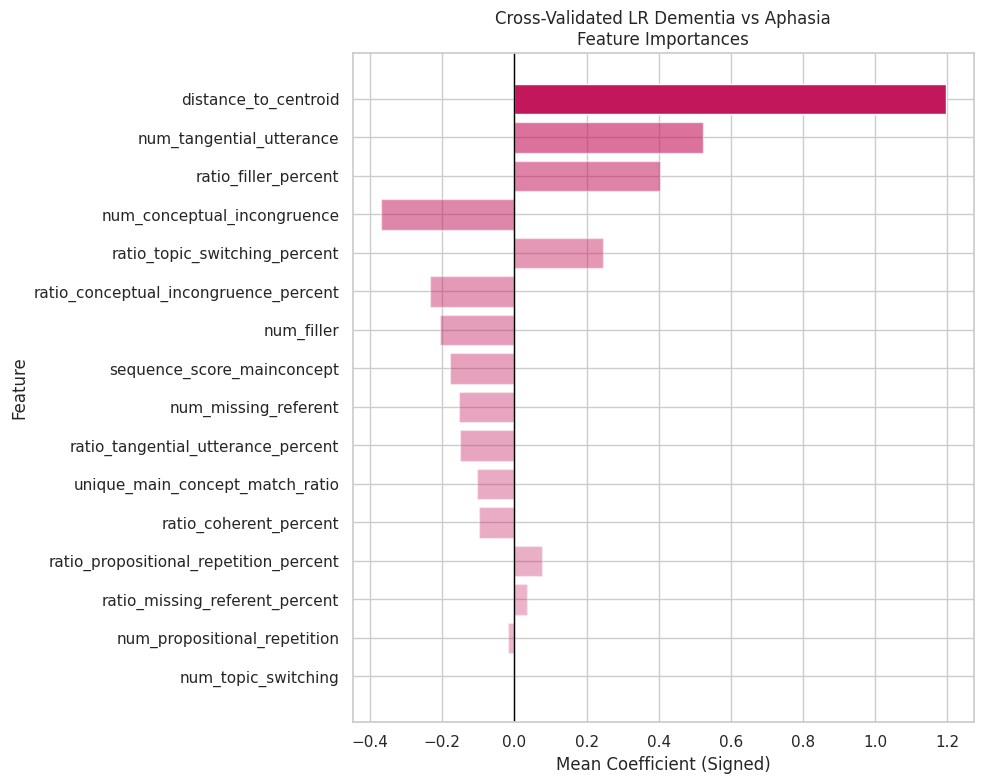

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize importance for alpha
abs_vals = importance_signed["mean_coef"].abs()
alpha_vals = 0.3 + 0.7 * (abs_vals / abs_vals.max())  # range [0.3, 1.0]

plt.figure(figsize=(10, 8))

for i, (feat, coef, alpha) in enumerate(
    zip(importance_signed.index,
        importance_signed["mean_coef"],
        alpha_vals)
):
    plt.barh(
        feat,
        coef,
        color="#C2185B",   # reddish-pink
        alpha=alpha
    )

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean Coefficient (Signed)")
plt.ylabel("Feature")
plt.title("Cross-Validated LR Dementia vs Aphasia\nFeature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Stability Check LOOCV

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=500,
        class_weight="balanced"
    ))
])

loo = LeaveOneOut()

coef_list = []
for train_idx, test_idx in loo.split(X, y):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_.ravel())

coef_loo = pd.DataFrame(coef_list, columns=X.columns)

# stability summary
votes_pos = (coef_loo > 0).sum()
votes_neg = (coef_loo < 0).sum()
n_folds = len(coef_loo)

summary = pd.DataFrame({
    "mean_coef": coef_loo.mean(),
    "std_coef": coef_loo.std(),
    "mean_abs_coef": coef_loo.abs().mean(),
    "votes_pos": votes_pos,
    "votes_neg": votes_neg,
    "n_folds": n_folds,
    "sign_consistency": (votes_pos - votes_neg).abs() / n_folds
}).sort_values("mean_abs_coef", ascending=False)
summary
# ---- PLOT ----
# TOP_N = 20
# top = summary.head(TOP_N).iloc[::-1]  # reverse for barh

# plt.figure(figsize=(10, 8))
# plt.barh(
#     top.index,
#     top["mean_coef"],
#     color=["green" if v > 0 else "red" for v in top["mean_coef"]]
# )
# plt.axvline(0, linestyle="--", linewidth=1)
# plt.xlabel("Mean LOOCV Coefficient (signed)")
# plt.title(f"LOOCV LR Coefficients (Aphasia vs Control) — Top {TOP_N} by mean |coef|")
# plt.tight_layout()
# plt.show()


,mean_coef,std_coef,mean_abs_coef,votes_pos,votes_neg,n_folds,sign_consistency
distance_to_centroid,1.197279,0.028054,1.197279,196,0,196,1.000000
num_tangential_utterance,0.502351,0.022394,0.502351,196,0,196,1.000000
ratio_filler_percent,0.397608,0.036623,0.397608,196,0,196,1.000000
num_conceptual_incongruence,-0.370730,0.025334,0.370730,0,196,196,1.000000
ratio_conceptual_incongruence_percent,-0.238430,0.017497,0.238430,0,196,196,1.000000
ratio_topic_switching_percent,0.234611,0.019344,0.234611,196,0,196,1.000000
num_filler,-0.208696,0.031326,0.208696,0,196,196,1.000000
sequence_score_mainconcept,-0.191911,0.016874,0.191911,0,196,196,1.000000
ratio_tangential_utterance_percent,-0.157421,0.019384,0.157421,0,196,196,1.000000
num_missing_referent,-0.150342,0.025948,0.150342,0,196,196,1.000000


In [116]:
import numpy as np
import pandas as pd

K = 10  # pick top-K features per fold (common: 5, 10, 20)

abs_coef = coef_loo.abs()

# boolean matrix: True if feature is in top-K abs coef in that fold
selected = abs_coef.apply(lambda row: row.nlargest(K).index, axis=1)

selected_mask = pd.DataFrame(False, index=coef_loo.index, columns=coef_loo.columns)
for i, feats in selected.items():
    selected_mask.loc[i, feats] = True

# selection frequency (%)
selection_freq = selected_mask.mean(axis=0) * 100  # percent
selection_freq = selection_freq.sort_values(ascending=False)

selection_freq.head(20)



distance_to_centroid                      100.000000
ratio_topic_switching_percent             100.000000
num_tangential_utterance                  100.000000
num_conceptual_incongruence               100.000000
ratio_conceptual_incongruence_percent     100.000000
ratio_filler_percent                      100.000000
sequence_score_mainconcept                 99.489796
num_filler                                 97.959184
ratio_tangential_utterance_percent         97.448980
num_missing_referent                       90.816327
unique_main_concept_match_ratio            11.224490
ratio_propositional_repetition_percent      2.551020
ratio_coherent_percent                      0.510204
num_topic_switching                         0.000000
ratio_missing_referent_percent              0.000000
num_propositional_repetition                0.000000
dtype: float64

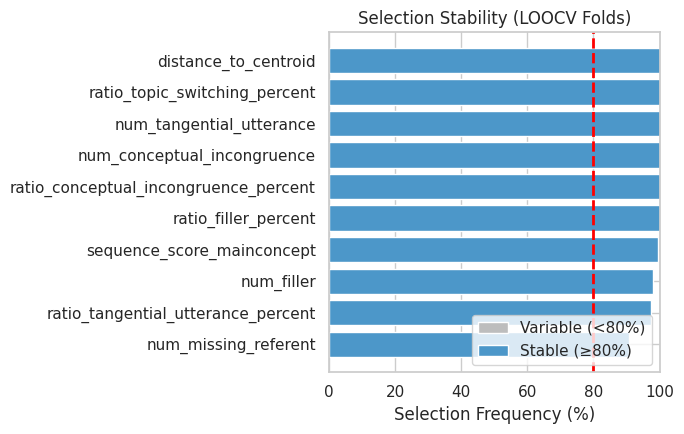

In [117]:
import matplotlib.pyplot as plt

THRESH = 80
TOP_N = 10

plot_series = selection_freq.head(TOP_N)[::-1]  # reverse for barh
colors = ["#4C97C9" if v >= THRESH else "#BDBDBD" for v in plot_series.values]

plt.figure(figsize=(7, 4.5))
plt.barh(plot_series.index, plot_series.values, color=colors)
plt.axvline(THRESH, color="red", linestyle="--", linewidth=2)

plt.xlabel("Selection Frequency (%)")
plt.title("Selection Stability (LOOCV Folds)")
plt.xlim(0, 100)

# legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor="#BDBDBD", label=f"Variable (<{THRESH}%)"),
    Patch(facecolor="#4C97C9", label=f"Stable (≥{THRESH}%)")
], loc="lower right")

plt.tight_layout()
plt.show()


In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeavePOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---- X, y (participant-level) ----
# assumes df_ml already created as you showed
y = df_ml["label"].copy()
X = df_ml.drop(columns=["participant", "label"], errors="ignore").copy()

# ---- model (same as yours) ----
pipe = Pipeline([
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=500,
        class_weight="balanced"
    ))
])

# ---- Leave-Two-Out CV ----
lpo = LeavePOut(p=2)

coef_list = []
for train_idx, test_idx in lpo.split(X, y):
    pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    coef_list.append(pipe.named_steps["clf"].coef_.ravel())

coef_lto = pd.DataFrame(coef_list, columns=X.columns)
n_folds = len(coef_lto)
print("LTOCV folds:", n_folds)  # should be 23005 for N=215

# ---- coefficient summary ----
votes_pos = (coef_lto > 0).sum()
votes_neg = (coef_lto < 0).sum()

summary_lto = pd.DataFrame({
    "mean_coef": coef_lto.mean(),
    "std_coef": coef_lto.std(),
    "mean_abs_coef": coef_lto.abs().mean(),
    "votes_pos": votes_pos,
    "votes_neg": votes_neg,
    "n_folds": n_folds,
    "sign_consistency": (votes_pos - votes_neg).abs() / n_folds
}).sort_values("mean_abs_coef", ascending=False)

summary_lto.head(20)


LTOCV folds: 19110


,mean_coef,std_coef,mean_abs_coef,votes_pos,votes_neg,n_folds,sign_consistency
distance_to_centroid,1.196677,0.039636,1.196677,19110,0,19110,1.000000
num_tangential_utterance,0.501979,0.031650,0.501979,19110,0,19110,1.000000
ratio_filler_percent,0.397459,0.051660,0.397459,19110,0,19110,1.000000
num_conceptual_incongruence,-0.370951,0.035846,0.370951,0,19110,19110,1.000000
ratio_conceptual_incongruence_percent,-0.238077,0.024772,0.238077,0,19110,19110,1.000000
ratio_topic_switching_percent,0.234773,0.027349,0.234773,19110,0,19110,1.000000
num_filler,-0.208095,0.044211,0.208150,12,19098,19110,0.998744
sequence_score_mainconcept,-0.191443,0.023875,0.191448,1,19109,19110,0.999895
ratio_tangential_utterance_percent,-0.156887,0.027407,0.156948,37,19073,19110,0.996128
num_missing_referent,-0.150168,0.036667,0.150175,5,19105,19110,0.999477


In [46]:
K = 10  # choose 5/10/20 depending on how many you want to “select”

abs_coef = coef_lto.abs()

# build boolean selection mask: selected if in top-K abs coef that fold
selected_mask = pd.DataFrame(False, index=abs_coef.index, columns=abs_coef.columns)

topk_idx_per_fold = abs_coef.apply(lambda row: row.nlargest(K).index, axis=1)
for i, feats in topk_idx_per_fold.items():
    selected_mask.loc[i, feats] = True

selection_freq = (selected_mask.mean(axis=0) * 100).sort_values(ascending=False)
selection_freq.head(20)


distance_to_centroid                      100.000000
unique_main_concept_match_ratio           100.000000
num_missing_referent                      100.000000
num_conceptual_incongruence               100.000000
ratio_filler_percent                      100.000000
num_filler                                100.000000
ratio_propositional_repetition_percent    100.000000
num_propositional_repetition              100.000000
ratio_conceptual_incongruence_percent      98.649219
num_tangential_utterance                   95.835092
ratio_missing_referent_percent              2.861029
ratio_coherent_percent                      0.984944
sequence_score_mainconcept                  0.848928
num_topic_switching                         0.712912
ratio_topic_switching_percent               0.075043
ratio_tangential_utterance_percent          0.032831
dtype: float64

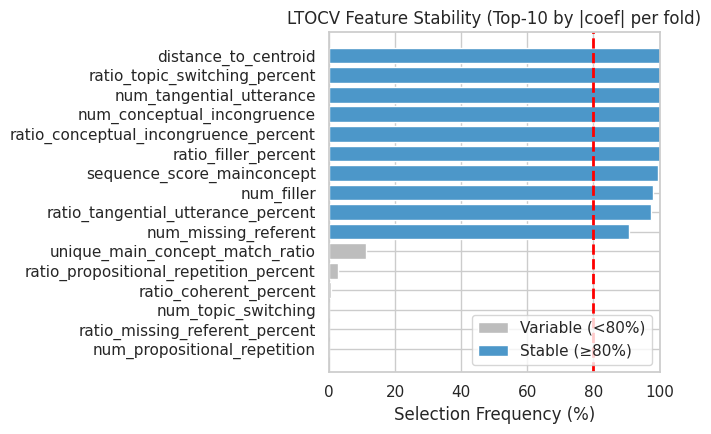

In [119]:
THRESH = 80
TOP_N = 16

plot_series = selection_freq.head(TOP_N)[::-1]
colors = ["#4C97C9" if v >= THRESH else "#BDBDBD" for v in plot_series.values]

plt.figure(figsize=(7, 4.5))
plt.barh(plot_series.index, plot_series.values, color=colors)
plt.axvline(THRESH, color="red", linestyle="--", linewidth=2)

plt.xlabel("Selection Frequency (%)")
plt.title(f"LTOCV Feature Stability (Top-{K} by |coef| per fold)")
plt.xlim(0, 100)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor="#BDBDBD", label=f"Variable (<{THRESH}%)"),
    Patch(facecolor="#4C97C9", label=f"Stable (≥{THRESH}%)")
], loc="lower right")

plt.tight_layout()
plt.show()
